In [1]:
#
#
#
import arslabrobotics as ar
import numpy as np

data = np.loadtxt("cart_data.txt")
(rows, _) = data.shape

arx = ar.identification.ARXSolver(data, 1, 0)
(a, b) = arx.solve()
# y(k) + a1 * y(k-1) + a2 * y(k-2) + .... = b1 * u(k) + b2 * u(k-1) * b3 * u(k-2) ... 

print(a,b)

[[-0.99100001]] [[0.00999999]]


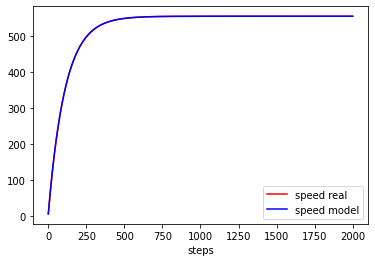

In [2]:
dp = ar.data.DataPlotter()
dp.set_x("steps")
dp.add_y("speed_r", "speed real")
dp.add_y("speed_m", "speed model")

system = ar.identification.ARXModel(a, b)
t = 0
for i in range(rows):
    u = data[i, 0]
    y = system.evaluate(u)
    dp.append_x(t)
    dp.append_y("speed_m", y)
    dp.append_y("speed_r", data[i,1])
    t += 1

dp.plot()

